# Notebook comparativo  
- MLP 
- simpleCNN 
- LeNet 
- AlexNet
- VGG
- NiN
- GoogLeNet
- ResNet


## 1) Import e funzioni comuni

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def get_loaders(batch_size=256, img_size=28):
    """FashionMNIST con resize opzionale."""
    tfm = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    train_ds = datasets.FashionMNIST("./data", train=True, download=True, transform=tfm)
    test_ds  = datasets.FashionMNIST("./data", train=False, download=True, transform=tfm)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

@torch.no_grad()
def accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        pred = model(X).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct / total

def train_model(model, train_loader, test_loader, epochs=5, lr=0.1):
    """Training loop didattico con logging e plot."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optim = torch.optim.SGD(model.parameters(), lr=lr)

    train_losses, train_accs, test_accs = [], [], []

    for ep in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            logits = model(X)
            loss = criterion(logits, y)

            optim.zero_grad()
            loss.backward()
            optim.step()

            running_loss += loss.item() * X.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

        ep_loss = running_loss / total
        ep_train_acc = correct / total
        ep_test_acc = accuracy(model, test_loader)

        train_losses.append(ep_loss)
        train_accs.append(ep_train_acc)
        test_accs.append(ep_test_acc)

        print(f"Epoca {ep:02d} | loss {ep_loss:.4f} | train acc {ep_train_acc:.4f} | test acc {ep_test_acc:.4f}")

    # Plot
    xs = range(1, epochs+1)
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(xs, train_losses, marker='o')
    plt.title("Loss di training")
    plt.xlabel("Epoca"); plt.ylabel("Loss"); plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(xs, train_accs, marker='o', label="Train")
    plt.plot(xs, test_accs,  marker='s', label="Test")
    plt.title("Accuracy")
    plt.xlabel("Epoca"); plt.ylabel("Accuracy"); plt.grid(True); plt.legend()

    plt.tight_layout()
    plt.show()

    return train_losses, train_accs, test_accs

Device: cpu


## 2) Modelli (builder functions)

**Due “regimi”**:

### Regime A — input 28×28 (velocissimo)
- `MLP28`
- `SimpleCNN28`
- `LeNet28`

### Regime B — input 96×96 (più “moderno”, ma ancora gestibile)
- `AlexNet96` (ridotta)
- `VGG96` (ridotta)
- `NiN96`
- `GoogLeNet96` (Inception semplificato)
- `ResNet96` (ResNet-like semplificata)

Tutti i modelli del regime B usano **AdaptiveAvgPool2d** per non dipendere da dimensioni fisse.

In [8]:
# -------- Regime A (28x28) --------
def build_mlp28():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(28*28, 256),
        nn.ReLU(),
        nn.Linear(256, 10)
    )

def build_simplecnn28():
    return nn.Sequential(
        nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
        nn.MaxPool2d(2),               # 28 -> 14
        nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
        nn.MaxPool2d(2),               # 14 -> 7
        nn.Flatten(),
        nn.Linear(32*7*7, 128), nn.ReLU(),
        nn.Linear(128, 10)
    )
def build_lenet28():
    return nn.Sequential(
        nn.Conv2d(1, 6, 5, padding=2), nn.ReLU(),    
        nn.AvgPool2d(2,2),
        nn.Conv2d(6, 16, 5), nn.ReLU(),              
        nn.AvgPool2d(2,2),
        nn.Flatten(),
        nn.Linear(16*5*5, 120), nn.ReLU(),           
        nn.Linear(120, 84), nn.ReLU(),              
        nn.Linear(84, 10)
    )

# -------- Regime B (96x96) --------
def build_alexnet96():
    return nn.Sequential(
        nn.Conv2d(1, 64, 11, stride=4, padding=2), nn.ReLU(),
        nn.MaxPool2d(3, stride=2),
        nn.Conv2d(64, 192, 5, padding=2), nn.ReLU(),
        nn.MaxPool2d(3, stride=2),
        nn.Conv2d(192, 384, 3, padding=1), nn.ReLU(),
        nn.Conv2d(384, 256, 3, padding=1), nn.ReLU(),
        nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
        nn.AdaptiveAvgPool2d((1,1)),
        nn.Flatten(),
        nn.Linear(256, 10)
    )

def vgg_block(num_convs, in_c, out_c):
    layers = []
    for i in range(num_convs):
        layers += [nn.Conv2d(in_c if i==0 else out_c, out_c, 3, padding=1), nn.ReLU()]
    layers += [nn.MaxPool2d(2,2)]
    return nn.Sequential(*layers)

def build_vgg96():
    features = nn.Sequential(
        vgg_block(1, 1, 32),
        vgg_block(1, 32, 64),
        vgg_block(2, 64, 128),
        vgg_block(2, 128, 256)
    )
    return nn.Sequential(
        features,
        nn.AdaptiveAvgPool2d((1,1)),
        nn.Flatten(),
        nn.Linear(256, 10)
    )

def nin_block(in_c, out_c, k, s, p):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, k, s, p), nn.ReLU(),
        nn.Conv2d(out_c, out_c, 1), nn.ReLU(),
        nn.Conv2d(out_c, out_c, 1), nn.ReLU(),
    )

def build_nin96():
    return nn.Sequential(
        nin_block(1,  64, 5, 2, 2),
        nn.MaxPool2d(3,2,1),
        nin_block(64, 128, 3, 1, 1),
        nn.MaxPool2d(3,2,1),
        nin_block(128, 256, 3, 1, 1),
        nn.AdaptiveAvgPool2d((1,1)),
        nn.Flatten(),
        nn.Linear(256, 10)
    )

class Inception(nn.Module):
    def __init__(self, in_c, c1, c3r, c3, c5r, c5, pool_proj):
        super().__init__()
        self.p1 = nn.Sequential(nn.Conv2d(in_c, c1, 1), nn.ReLU())
        self.p2 = nn.Sequential(nn.Conv2d(in_c, c3r, 1), nn.ReLU(),
                                nn.Conv2d(c3r, c3, 3, padding=1), nn.ReLU())
        self.p3 = nn.Sequential(nn.Conv2d(in_c, c5r, 1), nn.ReLU(),
                                nn.Conv2d(c5r, c5, 5, padding=2), nn.ReLU())
        self.p4 = nn.Sequential(nn.MaxPool2d(3, stride=1, padding=1),
                                nn.Conv2d(in_c, pool_proj, 1), nn.ReLU())
    def forward(self, x):
        return torch.cat([self.p1(x), self.p2(x), self.p3(x), self.p4(x)], dim=1)

def build_googlenet96():
    return nn.Sequential(
        nn.Conv2d(1, 64, 7, stride=2, padding=3), nn.ReLU(),
        nn.MaxPool2d(3,2,1),
        nn.Conv2d(64, 64, 1), nn.ReLU(),
        nn.Conv2d(64, 192, 3, padding=1), nn.ReLU(),
        nn.MaxPool2d(3,2,1),
        Inception(192, 64, 96, 128, 16, 32, 32),
        Inception(256, 128, 128, 192, 32, 96, 64),
        nn.MaxPool2d(3,2,1),
        Inception(480, 192, 96, 208, 16, 48, 64),
        nn.AdaptiveAvgPool2d((1,1)),
        nn.Flatten(),
        nn.Linear(512, 10)
    )

class BasicBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_c)
        self.relu = nn.ReLU()
        self.down = None
        if stride != 1 or in_c != out_c:
            self.down = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_c)
            )
    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.down is not None:
            identity = self.down(x)
        out = self.relu(out + identity)
        return out

def make_layer(in_c, out_c, n, stride):
    layers = [BasicBlock(in_c, out_c, stride)]
    for _ in range(1, n):
        layers.append(BasicBlock(out_c, out_c, 1))
    return nn.Sequential(*layers)

def build_resnet96():
    return nn.Sequential(
        nn.Conv2d(1, 64, 7, stride=2, padding=3, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(3,2,1),
        make_layer(64, 64, 2, 1),
        make_layer(64, 128, 2, 2),
        make_layer(128, 256, 2, 2),
        make_layer(256, 512, 2, 2),
        nn.AdaptiveAvgPool2d((1,1)),
        nn.Flatten(),
        nn.Linear(512, 10)
    )

MODELS = {
    "MLP28": build_mlp28,
    "SimpleCNN28": build_simplecnn28,
    "LeNet28": build_lenet28,
    "AlexNet96": build_alexnet96,
    "VGG96": build_vgg96,
    "NiN96": build_nin96,
    "GoogLeNet96": build_googlenet96,
    "ResNet96": build_resnet96
}

print("Modelli disponibili:", list(MODELS.keys()))

Modelli disponibili: ['MLP28', 'SimpleCNN28', 'LeNet28', 'AlexNet96', 'VGG96', 'NiN96', 'GoogLeNet96', 'ResNet96']


## 3) Esecuzione: 
- Scegliere un modello 
- Avviare training + plot

Modello selezionato: LeNet28
Sequential(
  (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (1): ReLU()
  (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (4): ReLU()
  (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=400, out_features=120, bias=True)
  (8): ReLU()
  (9): Linear(in_features=120, out_features=84, bias=True)
  (10): ReLU()
  (11): Linear(in_features=84, out_features=10, bias=True)
)
Epoca 01 | loss 1.2533 | train acc 0.5383 | test acc 0.7080
Epoca 02 | loss 0.6433 | train acc 0.7483 | test acc 0.7669
Epoca 03 | loss 0.5389 | train acc 0.7964 | test acc 0.8018
Epoca 04 | loss 0.4778 | train acc 0.8219 | test acc 0.7983
Epoca 05 | loss 0.4380 | train acc 0.8362 | test acc 0.8263
Epoca 06 | loss 0.4087 | train acc 0.8477 | test acc 0.8310
Epoca 07 | loss 0.3879 | train acc 0.8578 | test acc 0.8323
Epoca 08 | loss 0.3711 | trai

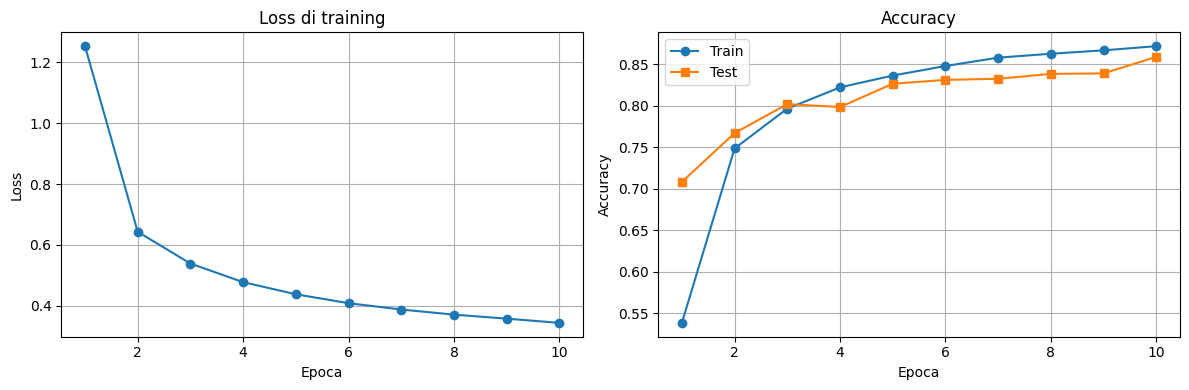

In [ ]:
# ====== PARAMETRI ======
MODEL_NAME = "LeNet28"    # es: "MLP28", "SimpleCNN28", "LeNet28", "ResNet96", ...
IMG_SIZE = 28                # 28 per Regime A, 96 per Regime B
BATCH_SIZE = 256 if IMG_SIZE == 28 else 128
EPOCHS = 10 if IMG_SIZE == 28 else 3
LR = 0.1 if IMG_SIZE == 28 else 0.01

# ========================

train_loader, test_loader = get_loaders(batch_size=BATCH_SIZE, img_size=IMG_SIZE)
model = MODELS[MODEL_NAME]().to(device)

print("Modello selezionato:", MODEL_NAME)
print(model)

train_losses, train_accs, test_accs = train_model(model, train_loader, test_loader, epochs=EPOCHS, lr=LR)

## 4) Confronto rapido tra più modelli


Training: MLP28 | IMG_SIZE: 28
Epoca 01 | loss 0.6691 | train acc 0.7638 | test acc 0.8057
Epoca 02 | loss 0.4660 | train acc 0.8318 | test acc 0.8107
Epoca 03 | loss 0.4215 | train acc 0.8486 | test acc 0.8426
Epoca 04 | loss 0.3927 | train acc 0.8577 | test acc 0.8384
Epoca 05 | loss 0.3751 | train acc 0.8641 | test acc 0.8450
Epoca 06 | loss 0.3569 | train acc 0.8708 | test acc 0.8546
Epoca 07 | loss 0.3433 | train acc 0.8766 | test acc 0.8503
Epoca 08 | loss 0.3328 | train acc 0.8798 | test acc 0.8569
Epoca 09 | loss 0.3233 | train acc 0.8840 | test acc 0.8343
Epoca 10 | loss 0.3141 | train acc 0.8868 | test acc 0.8401


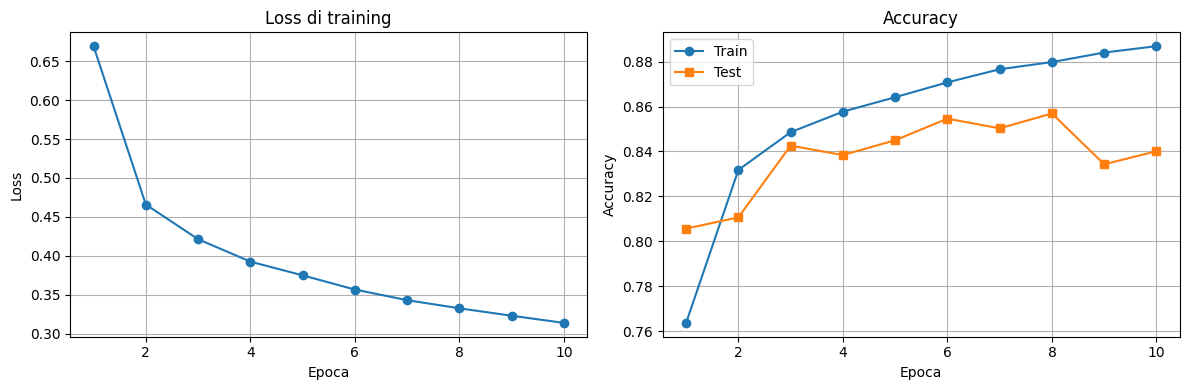


Training: SimpleCNN28 | IMG_SIZE: 28
Epoca 01 | loss 0.8894 | train acc 0.6752 | test acc 0.7825
Epoca 02 | loss 0.4645 | train acc 0.8290 | test acc 0.7727
Epoca 03 | loss 0.3923 | train acc 0.8550 | test acc 0.8437
Epoca 04 | loss 0.3553 | train acc 0.8688 | test acc 0.8627
Epoca 05 | loss 0.3272 | train acc 0.8800 | test acc 0.8435
Epoca 06 | loss 0.3122 | train acc 0.8855 | test acc 0.8707
Epoca 07 | loss 0.2932 | train acc 0.8922 | test acc 0.8562
Epoca 08 | loss 0.2813 | train acc 0.8970 | test acc 0.8901
Epoca 09 | loss 0.2684 | train acc 0.9009 | test acc 0.8747
Epoca 10 | loss 0.2587 | train acc 0.9047 | test acc 0.8899


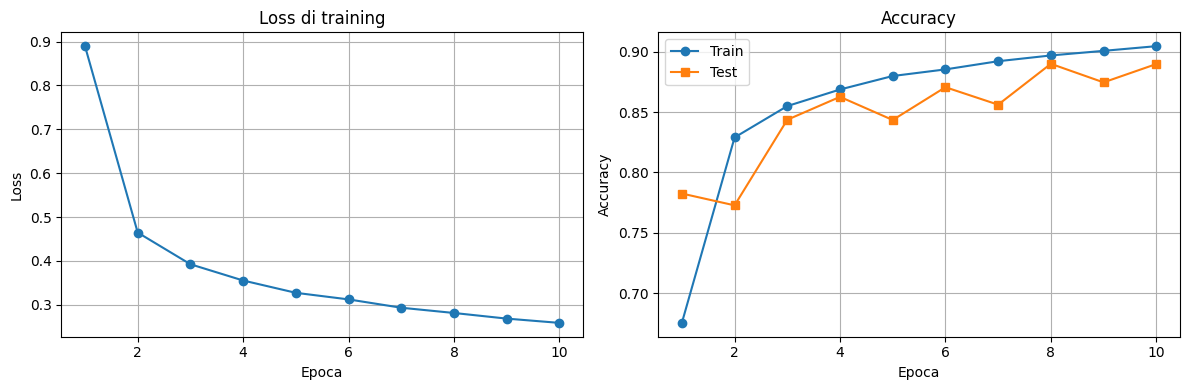


Training: LeNet28 | IMG_SIZE: 28
Epoca 01 | loss 1.3063 | train acc 0.5063 | test acc 0.6626
Epoca 02 | loss 0.6650 | train acc 0.7418 | test acc 0.7137
Epoca 03 | loss 0.5357 | train acc 0.7965 | test acc 0.8126
Epoca 04 | loss 0.4746 | train acc 0.8204 | test acc 0.8185
Epoca 05 | loss 0.4398 | train acc 0.8349 | test acc 0.8297
Epoca 06 | loss 0.4107 | train acc 0.8478 | test acc 0.8352
Epoca 07 | loss 0.3915 | train acc 0.8552 | test acc 0.8274
Epoca 08 | loss 0.3713 | train acc 0.8624 | test acc 0.8329
Epoca 09 | loss 0.3565 | train acc 0.8672 | test acc 0.8143
Epoca 10 | loss 0.3426 | train acc 0.8720 | test acc 0.8517


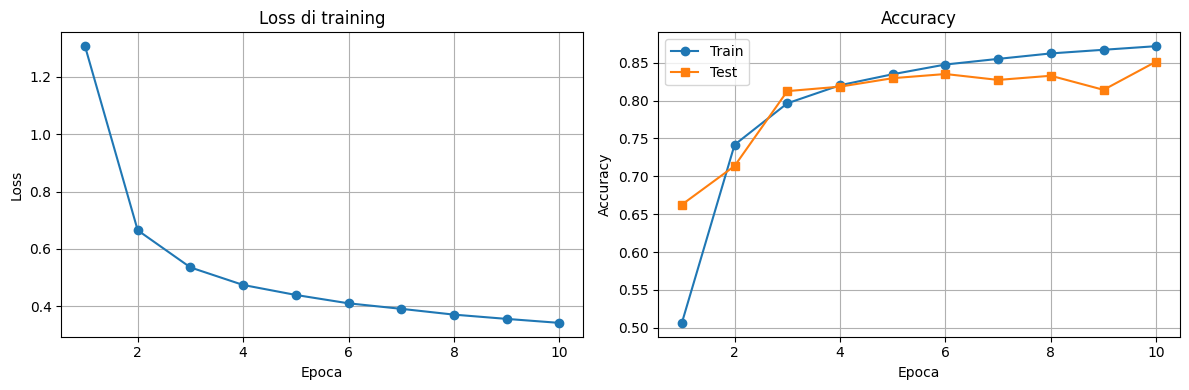


--- Accuracy finali (test) ---
SimpleCNN28 : 0.8899
LeNet28     : 0.8517
MLP28       : 0.8401


In [ ]:
# Scegli un set di modelli (NB: stesso regime!)
compare_models = ["MLP28", "SimpleCNN28", "LeNet28"]  # oppure: ["AlexNet96","VGG96","NiN96","GoogLeNet96","ResNet96"]
EPOCHS = 10

if all(name.endswith("28") for name in compare_models):
    IMG_SIZE = 28
    BATCH_SIZE = 256
    LR = 0.1
else:
    IMG_SIZE = 96
    BATCH_SIZE = 128
    LR = 0.01

train_loader, test_loader = get_loaders(batch_size=BATCH_SIZE, img_size=IMG_SIZE)

results = {}
for name in compare_models:
    print("\n==============================")
    print("Training:", name, "| IMG_SIZE:", IMG_SIZE)
    model = MODELS[name]().to(device)
    _, _, test_accs = train_model(model, train_loader, test_loader, epochs=EPOCHS, lr=LR)
    results[name] = test_accs[-1]

print("\n--- Accuracy finali (test) ---")
for k,v in sorted(results.items(), key=lambda kv: kv[1], reverse=True):
    print(f"{k:12s}: {v:.4f}")